In [1]:
import xarray as xr
import glob
import os
import calendar
import matplotlib.pyplot as plt
import numpy as np

In [2]:
######################################### FILE PATHS #########################################

idir = '/gws/pw/j25/rep/omerrett/git_upload/outputs'

In [3]:
# Import chlorphyll data from monthly_and_annual_average.py

AOWB = xr.open_dataset(f"{idir}/annual_surface_temp_aowb/aowb_monthly_and_annual_surface_temp_REGRID.nc")
OWB = xr.open_dataset(f"{idir}/annual_surface_temp_owb/owb_monthly_and_annual_surface_temp_REGRID.nc")
AOW = xr.open_dataset(f"{idir}/annual_surface_temp_aow/aow_monthly_and_annual_surface_temp_REGRID.nc")


In [4]:
# Import ostia in a useful format

ostia_ds = xr.open_dataset("/gws/pw/j25/rep/ostia/ostia_2018.nc")
sst = ostia_ds["analysed_sst"]

obs = {}
month_map = {i: calendar.month_name[i][:3].lower() for i in range(1, 13)}

# Extract each month, squeeze out the time dimension, and apply the land mask
for month_num, month_key in month_map.items():
    monthly_slice = sst.sel(time=sst.time.dt.month == month_num).squeeze()

    # Apply model land mask for each month
    obs[month_key] = monthly_slice.where(AOWB[f"{month_key}_temp"] != 0)

# Compute the annual average across all 12 months
monthly_list = [obs[m] for m in month_map.values()]
obs_combined = xr.concat(monthly_list, dim="time")
obs["annual"] = obs_combined.mean(dim="time")

print("Done! Dictionary keys:", list(obs.keys()))

Done! Dictionary keys: ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec', 'annual']


In [5]:
# Assemble model data into a similar structure as observations

AOWB_diff = {}
AOW_diff = {}
OWB_diff = {}
for m in obs.keys():
    print(f"Processing month: {m}")
    OWB_diff[m] = OWB[f"{m}_temp"] - (obs[m]-273.15)
    OWB[m] = OWB[f"{m}_temp"]
    
    AOWB_diff[m] = AOWB[f"{m}_temp"] - (obs[m]-273.15)
    AOWB[m] = AOWB[f"{m}_temp"]
   
    AOW_diff[m] = AOWB[f"{m}_temp"] - (obs[m]-273.15)
    AOW[m] = AOWB[f"{m}_temp"]


print('Done !')

Processing month: jan
Processing month: feb
Processing month: mar
Processing month: apr
Processing month: may
Processing month: jun
Processing month: jul
Processing month: aug
Processing month: sep
Processing month: oct
Processing month: nov
Processing month: dec
Processing month: annual
Done !


In [6]:
# Compute seasonal bias using indices
seasons = ['JF', 'MAM', 'JJA', 'SON']
season_indices = {
    'JF': ['jan', 'feb'],
    'MAM': ['mar', 'apr', 'may'],
    'JJA': ['jun', 'jul', 'aug'],
    'SON': ['sep', 'oct', 'nov']
}

# Dictionaries to hold the computed seasonal DataArrays
owb_seasonal = {}
aowb_seasonal = {}
aow_seasonal = {}

grid_template = OWB_diff['jan'].copy()

for s in seasons:
    keys = season_indices[s]
    
    owb_seasonal[s] = xr.concat([OWB_diff[k] for k in keys], dim='time').mean(dim='time', skipna=True)
    aowb_seasonal[s] = xr.concat([AOWB_diff[k] for k in keys], dim='time').mean(dim='time', skipna=True)
    aow_seasonal[s] = xr.concat([AOW_diff[k] for k in keys], dim='time').mean(dim='time', skipna=True)
    

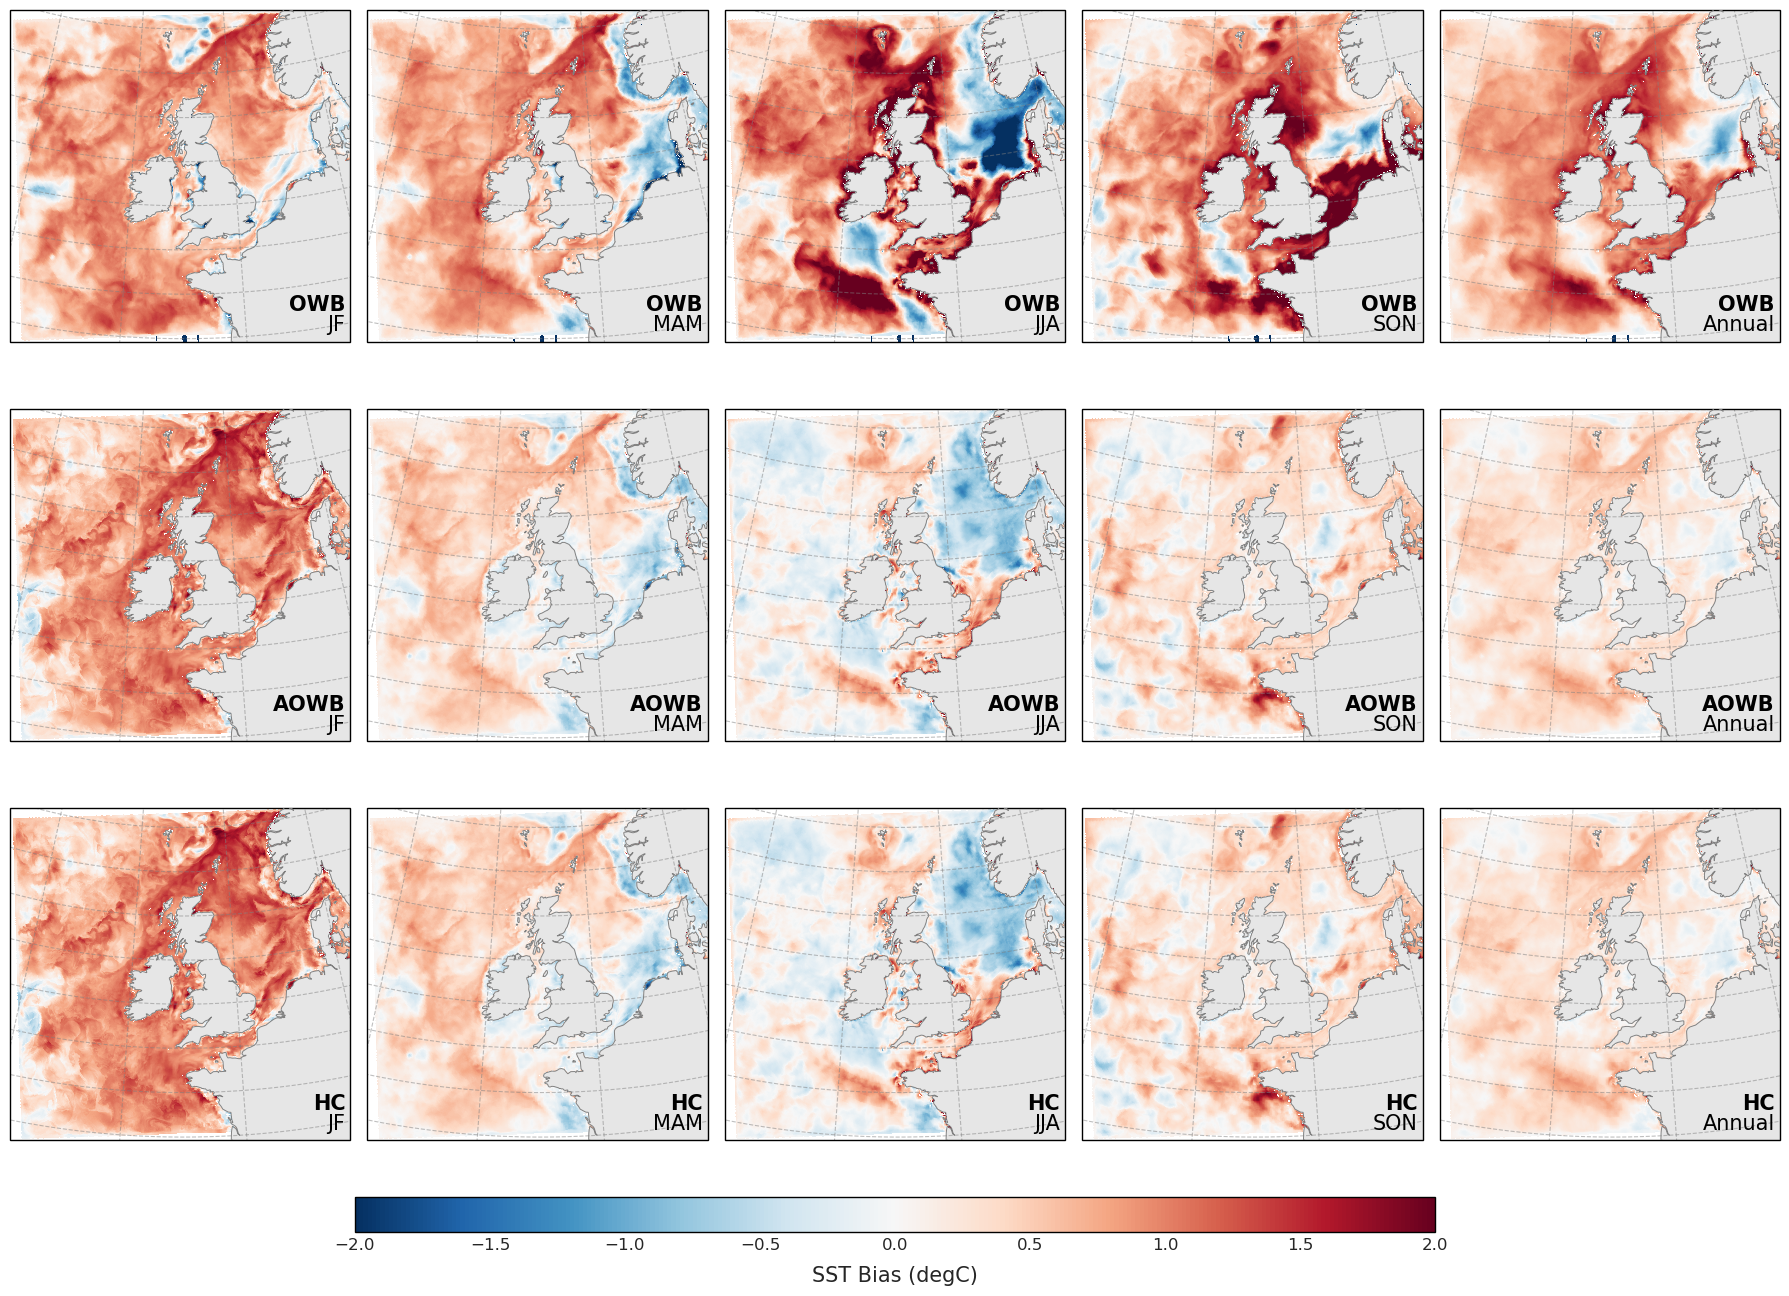

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.pyplot as plt

# Use the same plotting style throughout all plots
plt.style.use("seaborn-v0_8-whitegrid")

# Extent and projection for AMM15
TIGHT_EXTENT = [-18.5, 8, 44, 63]
NORTH_SEA_PROJECTION = ccrs.LambertConformal(
    central_longitude=-5, central_latitude=50.0, standard_parallels=(50.0, 60.0)
)

# Row configurations
row_configs = [
    {"dict": owb_seasonal, "annual": OWB_diff["annual"], "label": "OWB"},
    {"dict": aowb_seasonal, "annual": AOWB_diff["annual"], "label": "AOWB"},
    {"dict": aow_seasonal, "annual": AOW_diff["annual"], "label": "HC"},
]

seasons = ["JF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(
    nrows=3,
    ncols=5,
    figsize=(18, 14),
    subplot_kw={"projection": NORTH_SEA_PROJECTION},
)

vmin, vmax = -2.0, 2.0
cmap = plt.get_cmap("RdBu_r")
im = None

for row_idx, cfg in enumerate(row_configs):
    target_dict = cfg["dict"]
    annual_data = cfg["annual"]
    row_label = cfg["label"]

    for col_idx in range(5):
        ax = axes[row_idx, col_idx]

        if col_idx < 4:
            s = seasons[col_idx]
            data = target_dict[s]
            col_title = s
        else:
            data = annual_data
            col_title = "Annual"

        ax.add_feature(cfeature.LAND, facecolor="#E6E6E6", zorder=1)

        im = ax.pcolormesh(
            data["lon"],
            data["lat"],
            data,
            transform=ccrs.PlateCarree(),
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            zorder=2,
        )

        ax.set_extent(TIGHT_EXTENT, crs=ccrs.PlateCarree())
        ax.coastlines(resolution="50m", linewidth=0.7, color="grey", zorder=3)
        ax.gridlines(draw_labels=False, color="grey", linestyle="--", alpha=0.5)

        ax.set_title("")
        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.text(
            0.985,
            0.08,
            row_label,
            transform=ax.transAxes,
            fontsize=15,
            fontweight="bold",
            color="black",
            ha="right",
            va="bottom",
            zorder=4,
        )
        ax.text(
            0.985,
            0.08,
            col_title,
            transform=ax.transAxes,
            fontsize=15,
            color="black",
            ha="right",
            va="top",
            zorder=4,
        )

        for spine in ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(1)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15, hspace=0.06, wspace=0.05)

cbar_ax = fig.add_axes([0.2, 0.1, 0.6, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")

cbar.outline.set_edgecolor("black")
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("SST Bias (degC)", fontsize=15, labelpad=10)

plt.savefig("SST_Seasonal_3x5_Bias_Matrix.png", dpi=500, bbox_inches="tight")
plt.show()